In [ ]:
import numpy as np
from lorenz63 import lorenz
from matplotlib import pyplot as plt

In [6]:
times = np.arange(0, 50, 0.001)
xstate, ystate, zstate = -8, -8, 127
rho, beta, sigma = 28.0, 8.0/3.0, 10.0 #chaos
# rho, beta, sigma = 10, 8.0/3.0, 10.0   #spiral into one of two stable equilibria depending on initial conditions

out = lorenz(time_series=times, init_state=[xstate, ystate, zstate], parameters=[rho, beta, sigma])

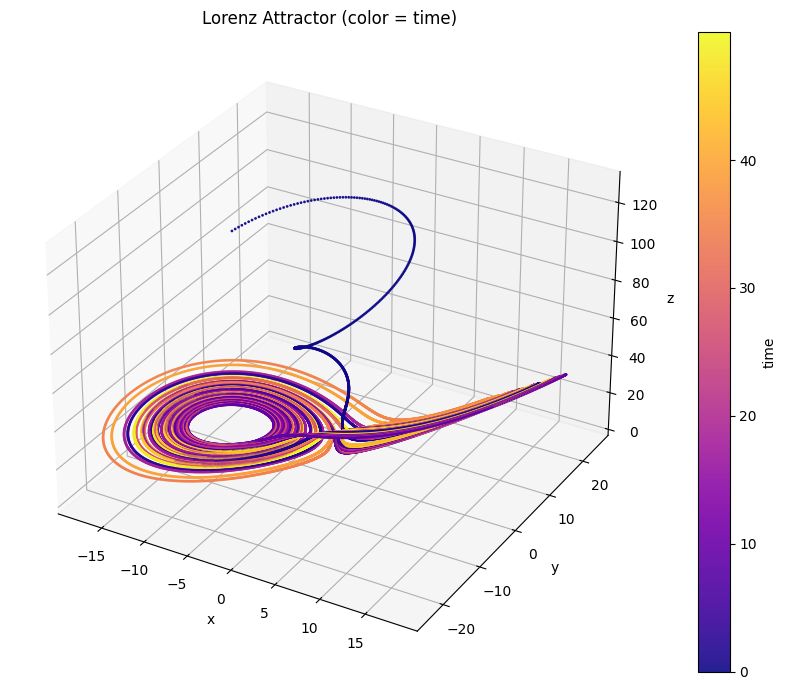

In [9]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')


sc = ax.scatter(
    out[:, 0], out[:, 1], out[:, 2],
    c=times, cmap='plasma', s=1, alpha=0.9
)

ax.set_title("Lorenz Attractor (color = time)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
fig.colorbar(sc, ax=ax, label="time")

plt.tight_layout()
plt.show()

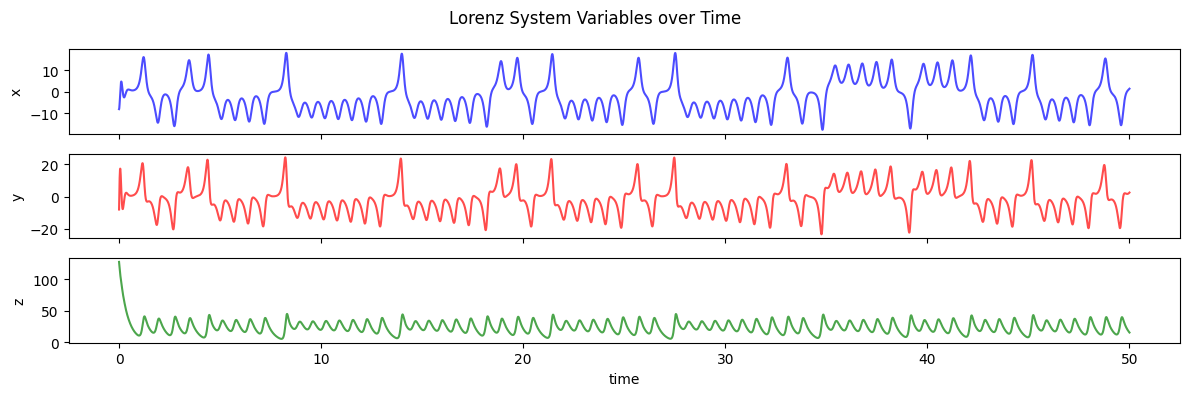

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(12, 4), sharex=True)

axes[0].plot(times, out[:, 0], color='blue', alpha=0.7)
axes[0].set_ylabel("x")

axes[1].plot(times, out[:, 1], color='red', alpha=0.7)
axes[1].set_ylabel("y")

axes[2].plot(times, out[:, 2], color='green', alpha=0.7)
axes[2].set_ylabel("z")
axes[2].set_xlabel("time")

fig.suptitle("Lorenz System Variables over Time")
plt.tight_layout()
plt.show()

In [26]:
# Split the z coordinate into train and test sets
train_size = int(0.8 * len(out))
z_train = out[1000:train_size, 2]
z_test = out[train_size:, 2]

t_train = times[1000:train_size]
t_test = times[train_size:]

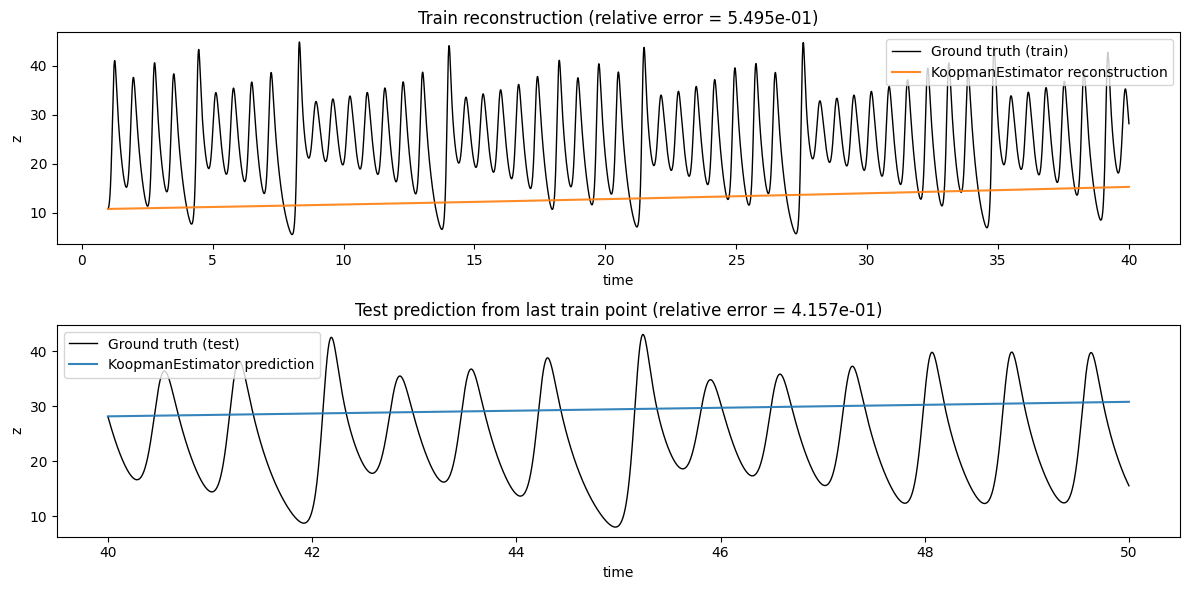

Estimated Koopman scalar K = 1.000009


In [27]:
# Linear Koopman model on z(t) using KoopmanEstimator
from koopman import KoopmanEstimator


lin_model = KoopmanEstimator(
    observable_type="polynomial",
    degree=1,
    include_bias=False,
    include_state=True,
    dt=times[1] - times[0],
    reg=1e-8,
    random_state=0,
)

# Fit on training trajectory (n_samples x n_states)
lin_model.fit(z_train.reshape(-1, 1))

# Training reconstruction (rollout from first training point)
z_train_rec = lin_model.reconstruct(np.array([z_train[0]]), n_steps=len(z_train) - 1)[:, 0]

# Test prediction (rollout from last training point)
z_test_pred = lin_model.predict(np.array([z_train[-1]]), steps=len(z_test))[0, :, 0]

# Relative errors vs ground truth
train_rel_err = np.linalg.norm(z_train_rec - z_train) / np.linalg.norm(z_train)
test_rel_err = np.linalg.norm(z_test_pred - z_test) / np.linalg.norm(z_test)

# Plots against ground truth
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=False)

axes[0].plot(t_train, z_train, label="Ground truth (train)", color="black", linewidth=1)
axes[0].plot(t_train, z_train_rec, label="KoopmanEstimator reconstruction", color="tab:orange", alpha=0.9)
axes[0].set_title(f"Train reconstruction (relative error = {train_rel_err:.3e})")
axes[0].set_xlabel("time")
axes[0].set_ylabel("z")
axes[0].legend()

axes[1].plot(t_test, z_test, label="Ground truth (test)", color="black", linewidth=1)
axes[1].plot(t_test, z_test_pred, label="KoopmanEstimator prediction", color="tab:blue", alpha=0.9)
axes[1].set_title(f"Test prediction from last train point (relative error = {test_rel_err:.3e})")
axes[1].set_xlabel("time")
axes[1].set_ylabel("z")
axes[1].legend()

plt.tight_layout()
plt.show()

K = np.real_if_close(lin_model.eigenvalues_discrete_[0]).item()
print(f"Estimated Koopman scalar K = {K:.6f}")

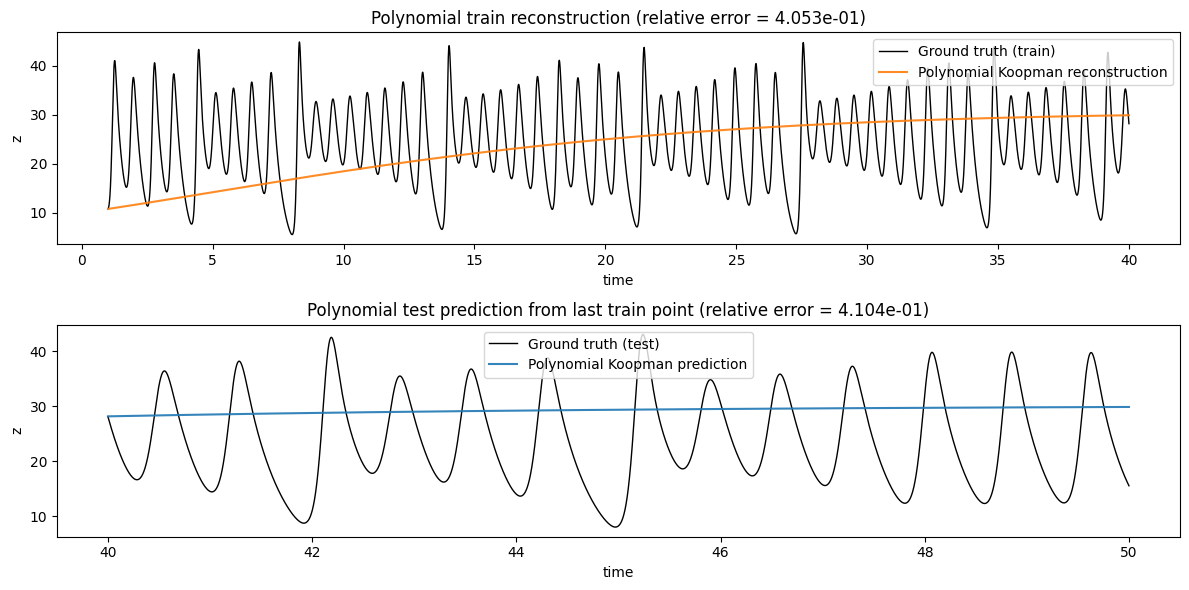

Polynomial Koopman observables: 4
Largest |lambda_d|: 1.000000
First 5 discrete eigenvalues: [1.        +0.00000000e+00j 0.9997628 +0.00000000e+00j
 0.99992095+4.93255023e-05j 0.99992095-4.93255023e-05j]
First 5 continuous eigenvalues: [-4.39204229e-10+0.j        -2.37224327e-01+0.j
 -7.90504357e-02+0.0493294j -7.90504357e-02-0.0493294j]


In [28]:
# Polynomial Koopman model on z(t) using KoopmanEstimator from koopman.py
from koopman import KoopmanEstimator


# EDMD with polynomial observables
poly_model = KoopmanEstimator(
    observable_type="polynomial",
    degree=3,
    include_bias=True,
    include_state=True,
    dt=times[1] - times[0],
    reg=1e-8,
    random_state=0,
)

# Fit on training trajectory (as column vector: n_samples x n_states)
poly_model.fit(z_train.reshape(-1, 1))

# Training reconstruction (rollout from first training point)
z_train_rec = poly_model.reconstruct(np.array([z_train[0]]), n_steps=len(z_train) - 1)[:, 0]

# Test prediction (rollout from last training point)
z_test_pred = poly_model.predict(np.array([z_train[-1]]), steps=len(z_test))[0, :, 0]

# Relative errors vs ground truth
train_rel_err = np.linalg.norm(z_train_rec - z_train) / np.linalg.norm(z_train)
test_rel_err = np.linalg.norm(z_test_pred - z_test) / np.linalg.norm(z_test)

# Plots against ground truth
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=False)

axes[0].plot(t_train, z_train, label="Ground truth (train)", color="black", linewidth=1)
axes[0].plot(t_train, z_train_rec, label="Polynomial Koopman reconstruction", color="tab:orange", alpha=0.9)
axes[0].set_title(f"Polynomial train reconstruction (relative error = {train_rel_err:.3e})")
axes[0].set_xlabel("time")
axes[0].set_ylabel("z")
axes[0].legend()

axes[1].plot(t_test, z_test, label="Ground truth (test)", color="black", linewidth=1)
axes[1].plot(t_test, z_test_pred, label="Polynomial Koopman prediction", color="tab:blue", alpha=0.9)
axes[1].set_title(f"Polynomial test prediction from last train point (relative error = {test_rel_err:.3e})")
axes[1].set_xlabel("time")
axes[1].set_ylabel("z")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Polynomial Koopman observables: {poly_model.n_observables_}")
print(f"Largest |lambda_d|: {np.max(np.abs(poly_model.eigenvalues_discrete_)):.6f}")
print("First 5 discrete eigenvalues:", poly_model.eigenvalues_discrete_[:5])
print("First 5 continuous eigenvalues:", poly_model.eigenvalues_continuous_[:5])

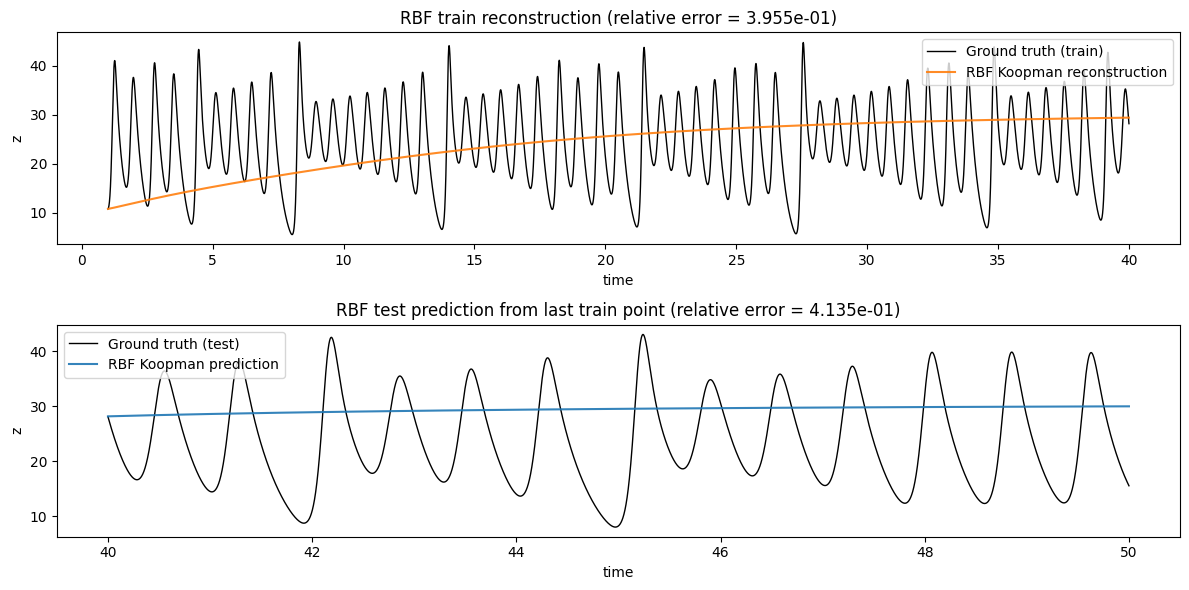

Largest |lambda_d|: 1.000000
First 5 discrete eigenvalues: [0.62688551+0.j 0.94062259+0.j 0.98562776+0.j 0.99031553+0.j
 0.99193838+0.j]
First 5 continuous eigenvalues: [-466.99135829+0.j  -61.21329628+0.j  -14.4765251 +0.j   -9.73166794+0.j
   -8.09429133+0.j]


In [30]:
# RBF Koopman model on z(t) using KoopmanEstimator
rbf_model = KoopmanEstimator(
    observable_type="rbf",
    include_bias=True,
    include_state=True,
    dt=times[1] - times[0],
    reg=1e-8,
    random_state=0,
    n_centers=200,   # tune as needed
    gamma=0.05,      # tune as needed
)

# Fit on training trajectory
rbf_model.fit(z_train.reshape(-1, 1))

# Training reconstruction
z_train_rec = rbf_model.reconstruct(np.array([z_train[0]]), n_steps=len(z_train) - 1)[:, 0]

# Test prediction
z_test_pred = rbf_model.predict(np.array([z_train[-1]]), steps=len(z_test))[0, :, 0]

# Relative errors
train_rel_err = np.linalg.norm(z_train_rec - z_train) / np.linalg.norm(z_train)
test_rel_err = np.linalg.norm(z_test_pred - z_test) / np.linalg.norm(z_test)

# Plots
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=False)

axes[0].plot(t_train, z_train, label="Ground truth (train)", color="black", linewidth=1)
axes[0].plot(t_train, z_train_rec, label="RBF Koopman reconstruction", color="tab:orange", alpha=0.9)
axes[0].set_title(f"RBF train reconstruction (relative error = {train_rel_err:.3e})")
axes[0].set_xlabel("time")
axes[0].set_ylabel("z")
axes[0].legend()

axes[1].plot(t_test, z_test, label="Ground truth (test)", color="black", linewidth=1)
axes[1].plot(t_test, z_test_pred, label="RBF Koopman prediction", color="tab:blue", alpha=0.9)
axes[1].set_title(f"RBF test prediction from last train point (relative error = {test_rel_err:.3e})")
axes[1].set_xlabel("time")
axes[1].set_ylabel("z")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Largest |lambda_d|: {np.max(np.abs(rbf_model.eigenvalues_discrete_)):.6f}")
print("First 5 discrete eigenvalues:", rbf_model.eigenvalues_discrete_[:5])
print("First 5 continuous eigenvalues:", rbf_model.eigenvalues_continuous_[:5])
